<a href="https://colab.research.google.com/github/ysuter/FHNW-BAI-ComputerVision/blob/main/W05_Uebung_StereoTiefe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Übung 5 – Von 2D zu 3D: Stereovision & Tiefenrekonstruktion
## Computer Vision | FS 2026

**Lernziele dieser Übung:**
- Die Beziehung zwischen Disparität und Tiefe ($Z = f \cdot B / d$) anwenden
- Eine Disparitätskarte mit Block Matching berechnen
- Tiefenwerte aus Disparität zurückgewinnen und visualisieren
- Den Einfluss der Kameraparameter auf die Tiefenauflösung analysieren

**Hilfsmittel:** Python, OpenCV, NumPy, Matplotlib  
**Zeitrahmen:** ca. 15 Minuten

## Setup – bitte zuerst ausführen

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

plt.rcParams['figure.dpi'] = 100
print("✓ Bereit!")

✓ Bereit!


---
## Aufgabe 0 – Synthetisches Stereo-Bildpaar laden

Die folgende Zelle erzeugt ein synthetisches Stereo-Bildpaar und gibt euch alle nötigen Kameraparameter.  
**Führt diese Zelle aus, ohne sie zu ändern.**

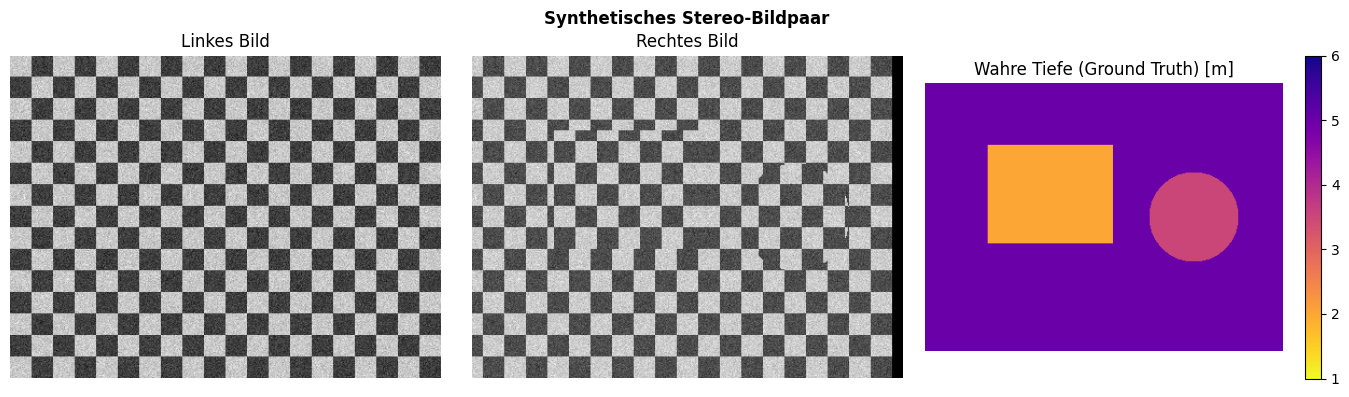

Kameraparameter: f=400.0 px, B=0.12 m
Wahre Disparitäten: Rechteck=24.0px, Kreis=13.7px, Hintergr.=9.6px


In [2]:
# ── Kameraparameter (NICHT ÄNDERN) ───────────────────────────────────────
f  = 400.0    # Brennweite [Pixel]
B  = 0.12     # Baseline (Kameraabstand) [Meter]
h, w = 300, 400

# Synthetische Szene: Tiefenkarte mit 3 Tiefen
depth_gt = np.full((h, w), 5.0)          # Hintergrund: 5 m
depth_gt[70:180, 70:210]  = 2.0          # Rechteck vorne: 2 m
Ys, Xs = np.ogrid[:h, :w]
depth_gt[(Xs-300)**2 + (Ys-150)**2 < 50**2] = 3.5  # Kreis: 3.5 m

# Erzeuge Textur (Schachbrett + Rauschen)
np.random.seed(42)
left_img = np.zeros((h, w), dtype=np.float32)
for i in range(0, h, 20):
    for j in range(0, w, 20):
        left_img[i:i+20, j:j+20] = 0.8 if (i//20 + j//20) % 2 == 0 else 0.3
left_img += np.random.normal(0, 0.05, left_img.shape)
left_img = np.clip(left_img, 0, 1)

# Wahre Disparität und rechtes Bild generieren
true_disp = (f * B / depth_gt).astype(np.float32)
right_img = np.zeros_like(left_img)
for y in range(h):
    for x in range(w):
        src_x = x + int(round(true_disp[y, x]))
        if 0 <= src_x < w:
            right_img[y, x] = left_img[y, src_x]

left_u8  = (left_img * 255).astype(np.uint8)
right_u8 = (right_img * 255).astype(np.uint8)

# Visualisierung
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(left_u8,  cmap='gray'); axes[0].set_title('Linkes Bild');  axes[0].axis('off')
axes[1].imshow(right_u8, cmap='gray'); axes[1].set_title('Rechtes Bild'); axes[1].axis('off')
im = axes[2].imshow(depth_gt, cmap='plasma_r', vmin=1, vmax=6)
axes[2].set_title('Wahre Tiefe (Ground Truth) [m]'); axes[2].axis('off')
plt.colorbar(im, ax=axes[2])
plt.suptitle('Synthetisches Stereo-Bildpaar', fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Kameraparameter: f={f} px, B={B} m")
print(f"Wahre Disparitäten: Rechteck={true_disp[120,100]:.1f}px, Kreis={true_disp[150,300]:.1f}px, Hintergr.={true_disp[10,10]:.1f}px")

---
## Aufgabe 1 – Disparität → Tiefe (Formel anwenden)

Die Tiefe $Z$ ergibt sich aus der Disparität $d$ nach:

$$Z = \frac{f \cdot B}{d}$$

**Eure Aufgabe:** Berechnet für die drei Objekte manuell die erwartete Disparität und Tiefe.

| Objekt | Tiefe Z [m] | Erwartete Disparität d [px] |
|--------|-------------|----------------------------|
| Rechteck | 2.0 m | ??? |
| Kreis | 3.5 m | ??? |
| Hintergrund | 5.0 m | ??? |

Ergänzt die Berechnung im Code:

In [3]:
# Aufgabe 1a: Berechnet die erwartete Disparität für jedes Objekt
# Formel: d = f * B / Z

Z_rechteck    = 2.0
Z_kreis       = 3.5
Z_hintergrund = 5.0

# ToDo
d_rechteck    = ?   # Ergänzen!
d_kreis       = ?   # Ergänzen!
d_hintergrund = ?   # Ergänzen!

print(f"Rechteck:    Z={Z_rechteck}m  → Disparität d={d_rechteck:.2f} px")
print(f"Kreis:       Z={Z_kreis}m  → Disparität d={d_kreis:.2f} px")
print(f"Hintergrund: Z={Z_hintergrund}m  → Disparität d={d_hintergrund:.2f} px")

SyntaxError: invalid syntax (3189265853.py, line 8)

In [4]:
# Aufgabe 1b: Verifikation – vergleicht eure Werte mit den wahren Disparitäten
print("Wahre Disparitäten aus der generierten Szene:")
print(f"  Rechteck:    {true_disp[120, 100]:.2f} px")
print(f"  Kreis:       {true_disp[150, 300]:.2f} px")
print(f"  Hintergrund: {true_disp[10, 10]:.2f} px")

# Stimmen eure Werte überein?

Wahre Disparitäten aus der generierten Szene:
  Rechteck:    24.00 px
  Kreis:       13.71 px
  Hintergrund: 9.60 px


---
## Aufgabe 2 – Disparitätskarte berechnen

Mit OpenCV's `StereoBM`-Algorithmus berechnen wir die Disparitätskarte aus dem Bildpaar.

**Hinweis:** `stereo.compute()` gibt Werte als Festkommazahlen zurück – durch 16 dividieren!

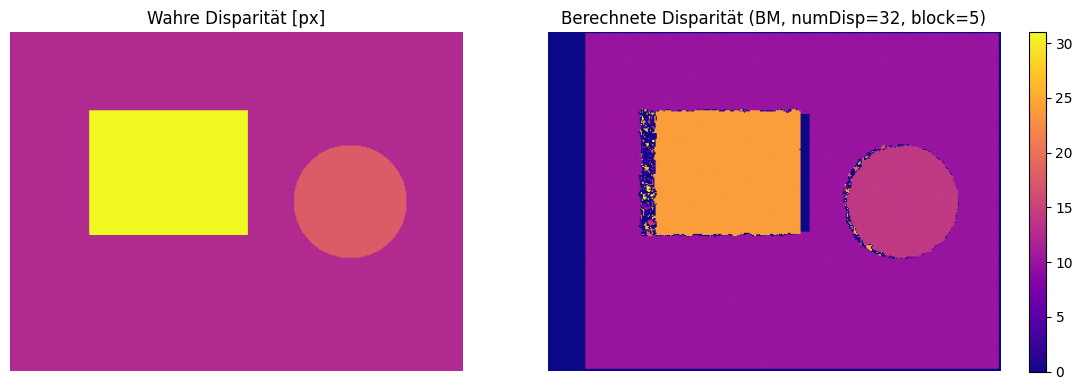

In [6]:
# Aufgabe 2: StereoBM konfigurieren und Disparität berechnen
# Dokumentation: cv2.StereoBM_create(numDisparities, blockSize)
# - numDisparities: Anzahl Disparitätsstufen (Vielfaches von 16)
# - blockSize: Blockgrösse für Matching (ungerade Zahl)

num_disp = 32   # Wählt einen Wert (z.B. 32, 64 oder 96 – muss Vielfaches von 16 sein)
block_sz = 5   # Wählt einen Wert (z.B. 5, 11 oder 15 – muss ungerade sein)

stereo = cv2.StereoBM_create(numDisparities=num_disp, blockSize=block_sz)
disp_fixed = stereo.compute(left_u8, right_u8)  # Festkomma-Ausgabe

# WICHTIG: Durch 16 dividieren für echte Pixelwerte
disp_float = disp_fixed.astype(np.float32) / 16

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(true_disp, cmap='plasma', vmin=0)
axes[0].set_title('Wahre Disparität [px]'); axes[0].axis('off')
im = axes[1].imshow(disp_float.clip(0, num_disp), cmap='plasma')
axes[1].set_title(f'Berechnete Disparität (BM, numDisp={num_disp}, block={block_sz})'); axes[1].axis('off')
plt.colorbar(im, ax=axes[1])
plt.tight_layout(); plt.show()

---
## Aufgabe 3 – Tiefenkarte rekonstruieren

Wandelt die berechnete Disparitätskarte in eine Tiefenkarte um.

**Achtung:** Pixel mit Disparität ≤ 0 sind ungültig (kein Match gefunden) → setzt diese Werte auf `nan`!

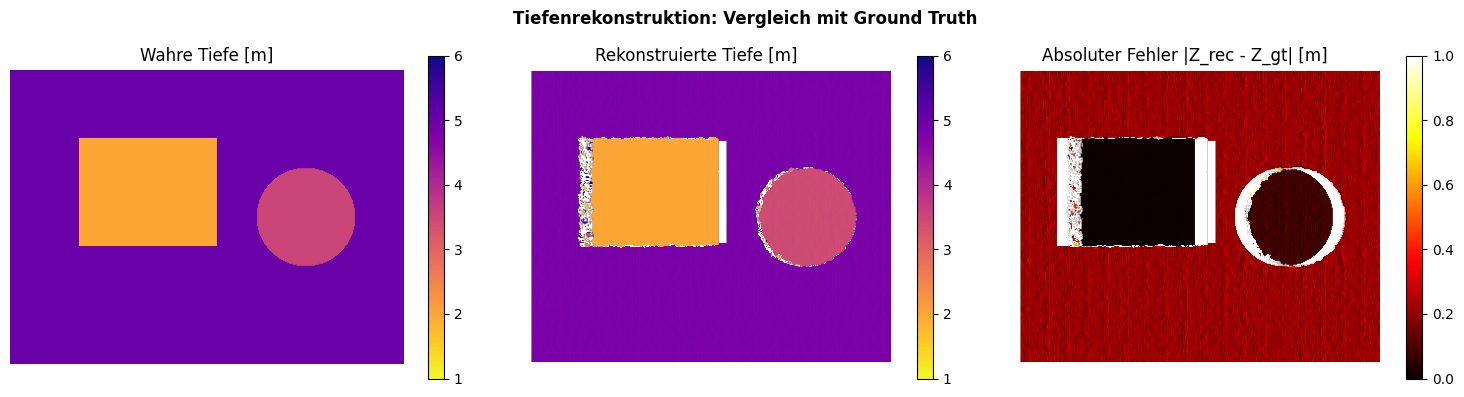

In [10]:
# Aufgabe 3a: Tiefenkarte aus Disparität berechnen
# Formel: Z = f * B / d  (aber nur für d > 0!)

# Erstellt eine Kopie und setzt ungültige Pixel auf nan
disp_valid = disp_float.copy()
disp_valid[disp_valid <= 0] = np.nan  # ungültige Pixel markieren

# Tiefenkarte berechnen
depth_recovered = f*B / disp_valid  # Formel hier eintragen!

# Visualisierung: Vergleich mit Ground Truth
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(depth_gt, cmap='plasma_r', vmin=1, vmax=6)
axes[0].set_title('Wahre Tiefe [m]'); axes[0].axis('off')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(depth_recovered, cmap='plasma_r', vmin=1, vmax=6)
axes[1].set_title('Rekonstruierte Tiefe [m]'); axes[1].axis('off')
plt.colorbar(im1, ax=axes[1])

# Fehler (absolut)
error = np.abs(depth_recovered - depth_gt)
im2 = axes[2].imshow(error, cmap='hot', vmin=0, vmax=1)
axes[2].set_title('Absoluter Fehler |Z_rec - Z_gt| [m]'); axes[2].axis('off')
plt.colorbar(im2, ax=axes[2])

plt.suptitle('Tiefenrekonstruktion: Vergleich mit Ground Truth', fontweight='bold')
plt.tight_layout(); plt.show()

In [11]:
# Aufgabe 3b: Tiefenfehler auswerten
# Berechnet den mittleren absoluten Fehler (MAE) für jedes Objekt

# Masken für die drei Regionen
mask_rect = np.zeros((h, w), dtype=bool)
mask_rect[70:180, 70:210] = True

mask_circ = np.zeros((h, w), dtype=bool)
mask_circ[(Xs-300)**2 + (Ys-150)**2 < 50**2] = True

mask_bg = ~mask_rect & ~mask_circ

for name, mask in [('Rechteck (2m)', mask_rect), ('Kreis (3.5m)', mask_circ), ('Hintergrund (5m)', mask_bg)]:
    region_gt  = depth_gt[mask]
    region_rec = depth_recovered[mask]
    valid = ~np.isnan(region_rec)
    if valid.sum() > 0:
        mae = np.mean(np.abs(region_rec[valid] - region_gt[valid]))
        coverage = 100 * valid.sum() / len(region_gt)
        print(f"{name:25s}: MAE = {mae:.3f} m, Abdeckung = {coverage:.1f}%")
    else:
        print(f"{name:25s}: Keine gültigen Pixel!")

Rechteck (2m)            : MAE = 0.405 m, Abdeckung = 93.0%
Kreis (3.5m)             : MAE = 0.289 m, Abdeckung = 96.2%
Hintergrund (5m)         : MAE = 0.280 m, Abdeckung = 86.6%


---
## Aufgabe 4 (Bonus) – Einfluss der Kameraparameter

Untersucht, wie Brennweite $f$ und Baseline $B$ die Tiefenauflösung beeinflussen.

**Frage:** Was passiert, wenn ihr $B$ verdoppelt oder halbiert?  
Wie verändert sich die minimale und maximale messbare Tiefe?

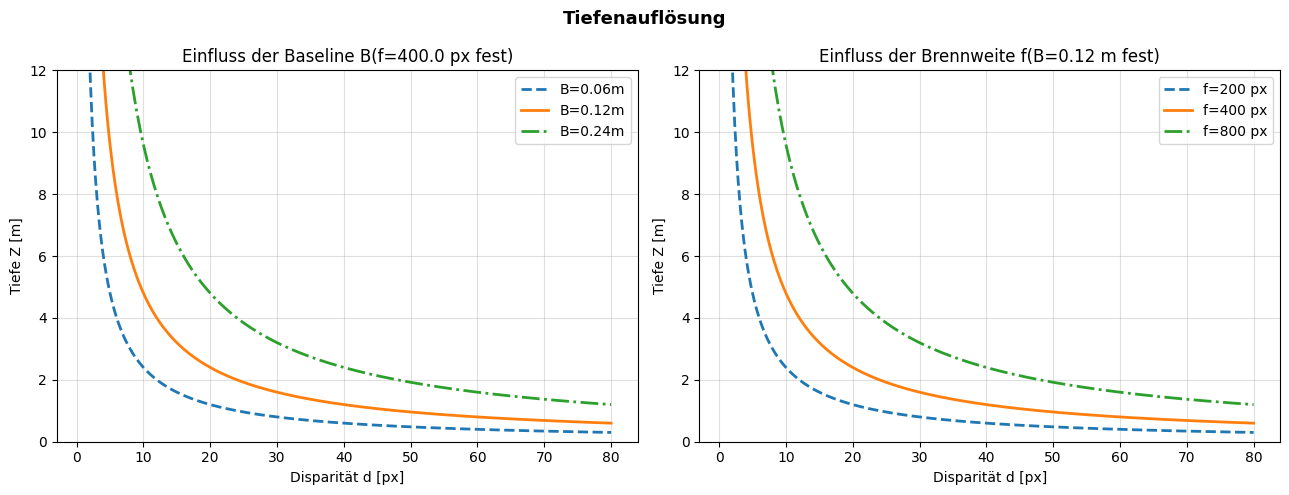

Diskutiert: Was sind die Trade-offs bei der Wahl von B und f?


In [16]:
# Bonusaufgabe: Tiefenauflösung als Funktion von f und B
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

d_range = np.linspace(1, 80, 300)  # Disparität in Pixel

# Vergleich verschiedener Baselines (f fest)
for B_var, ls in [(0.06, '--'), (0.12, '-'), (0.24, '-.')]:
    Z_var = f * B_var / d_range
    axes[0].plot(d_range, Z_var, linestyle=ls, linewidth=2, label=f'B={B_var}m')

axes[0].set_xlabel('Disparität d [px]')
axes[0].set_ylabel('Tiefe Z [m]')
axes[0].set_title(f'Einfluss der Baseline B(f={f} px fest)')
axes[0].set_ylim(0, 12)
axes[0].legend(); axes[0].grid(True, alpha=0.4)

# Vergleich verschiedener Brennweiten (B fest)
for f_var, ls in [(200, '--'), (400, '-'), (800, '-.')]:
    Z_var = f_var * B / d_range
    axes[1].plot(d_range, Z_var, linestyle=ls, linewidth=2, label=f'f={f_var} px')

axes[1].set_xlabel('Disparität d [px]')
axes[1].set_ylabel('Tiefe Z [m]')
axes[1].set_title(f'Einfluss der Brennweite f(B={B} m fest)')
axes[1].set_ylim(0, 12)
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.suptitle('Tiefenauflösung', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Beantwortet in eurem eigenen Worten:
# 1. Was bewirkt eine grössere Baseline?
# 2. Was ist der Nachteil einer sehr grossen Baseline?
# 3. Für welche Anwendungen würdet ihr eine grosse / kleine Baseline wählen?
print("Diskutiert: Was sind die Trade-offs bei der Wahl von B und f?")

---
## Lösungshinweise

<details>
<summary>Aufgabe 1 – Disparität berechnen (aufklappen)</summary>

```python
d = f * B / Z
d_rechteck    = f * B / Z_rechteck    # = 400 * 0.12 / 2.0  = 24.0 px
d_kreis       = f * B / Z_kreis       # = 400 * 0.12 / 3.5  ≈ 13.7 px
d_hintergrund = f * B / Z_hintergrund # = 400 * 0.12 / 5.0  =  9.6 px
```
</details>

<details>
<summary>Aufgabe 2 – StereoBM (aufklappen)</summary>

```python
num_disp = 64   # oder 32
block_sz = 11   # oder 15
stereo = cv2.StereoBM_create(numDisparities=num_disp, blockSize=block_sz)
disp_float = disp_fixed.astype(np.float32) / 16.0
```
</details>

<details>
<summary>Aufgabe 3 – Tiefenkarte (aufklappen)</summary>

```python
disp_valid[disp_valid <= 0] = np.nan
depth_recovered = f * B / disp_valid
```
</details>